## Data Import

In [1]:
#Import modules
import sys
import os
print(os.getcwd())
sys.path.append('../')
sys.path.append('../modules/')
sys.path.append('../../PARAM_GEN/')
from Class_sem2dpack import *
from Stage_module import *
from houches_fb import *
from Soil_Models import Volvi, Rome
from scipy.interpolate import griddata, interp1d
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as anim

#Load data
direct1 = "C:/Users/t.guyonneau/OneDrive - EGIS Group/Documents/OUTPUT/Preno_Rome"
is_overburden = False
fmin, fmax = 0.01, 50
SEM = sem2dpack(direct1)
SEM.read_seismo('x')
SEM.filter_seismo(fmax=fmax, ftype='lowpass')
SEM.filter_seismo(fmin=fmin, ftype='highpass')
Time_stations = SEM.time
Vx = SEM.velocity[:,:]
XSTA, ZSTA = SEM.rcoord[:,0], SEM.rcoord[:,1]

model = Rome


c:\Users\t.guyonneau\OneDrive - EGIS Group\Documents\GitHub\sem2dpack\JUPYTER\Stage_Theo
Reading grid information...
Reading header file...
0.00014 35715 561
--- No extra station ---
*
Filtering seissmograms ...


c:\Users\t.guyonneau\OneDrive - EGIS Group\Documents\GitHub\sem2dpack\JUPYTER\Stage_Theo\..\Class_sem2dpack.py:330: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  line = pd.read_csv(fname, delim_whitespace=True, header=None, nrows=1, dtype=int)
c:\Users\t.guyonneau\OneDrive - EGIS Group\Documents\GitHub\sem2dpack\JUPYTER\Stage_Theo\..\Class_sem2dpack.py:331: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(fname, names=('x','z'), delim_whitespace=True, header=0, nrows=line.values[0][0])
c:\Users\t.guyonneau\OneDrive - EGIS Group\Documents\GitHub\sem2dpack\JUPYTER\Stage_Theo\..\Class_sem2dpack.py:365: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(fname, header=0, n

Filtering seissmograms ...


## Input Signal

c:\Users\t.guyonneau\OneDrive - EGIS Group\Documents\GitHub\sem2dpack\JUPYTER\Stage_Theo\../modules\Stage_module.py:269: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax_F.set_xlim(0,50)


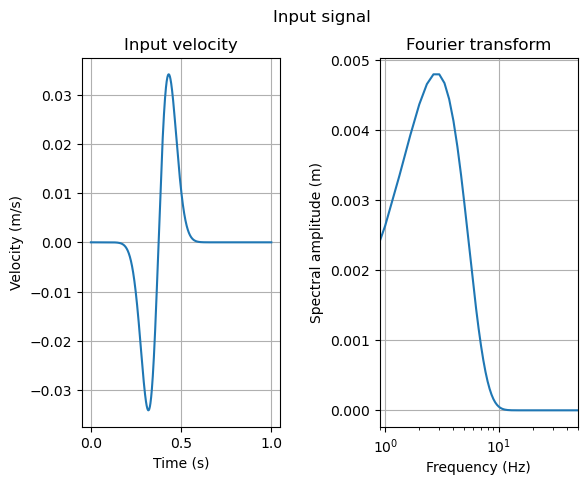

In [2]:
plot_input_signal(SEM.directory+'/inputp1', 'VF', pad=3)

## Seismograms

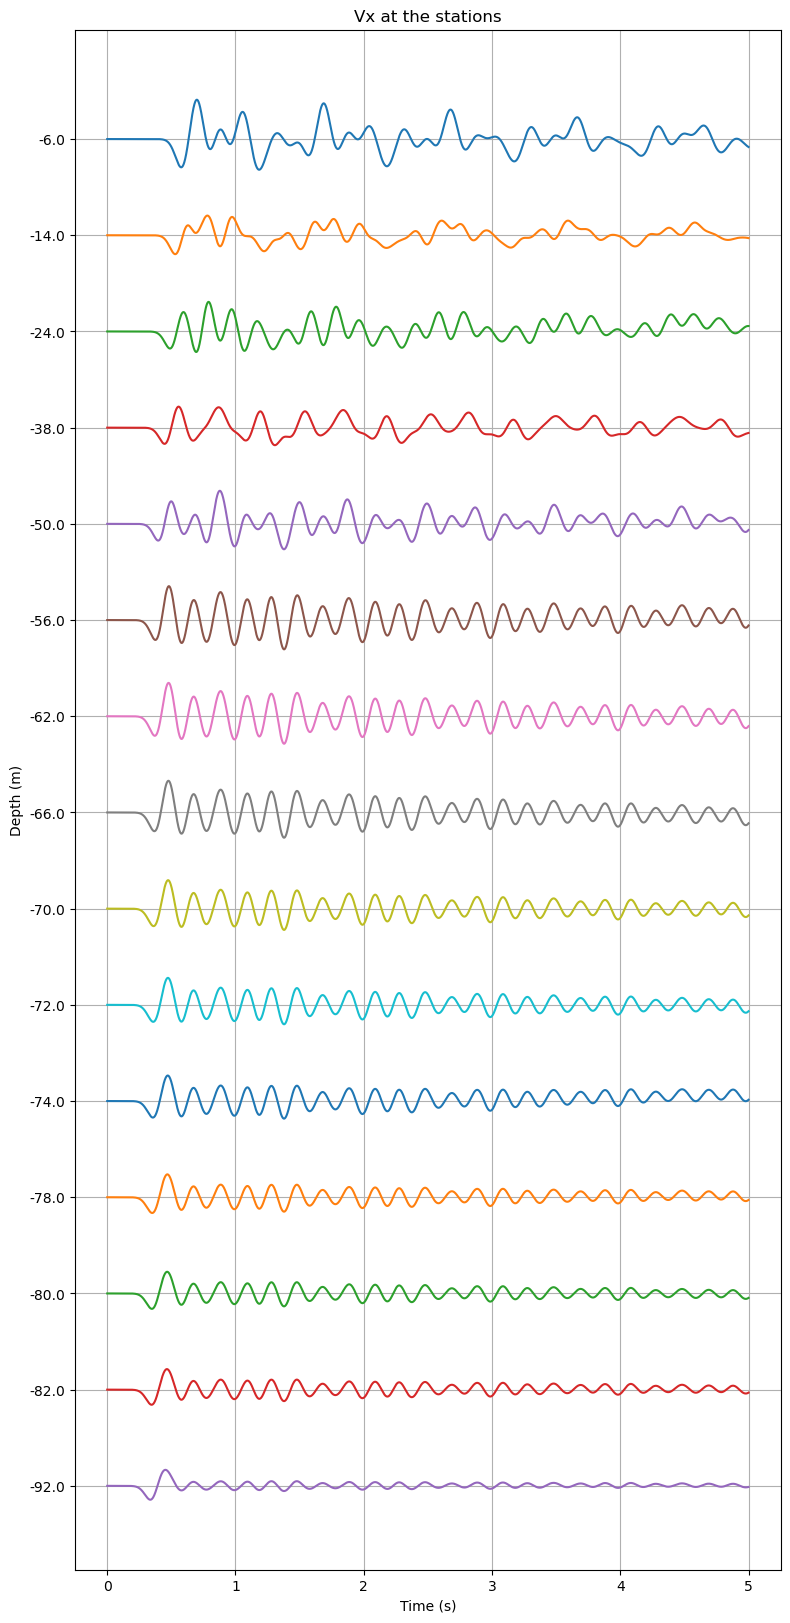

In [3]:
def plot_layers_seismogram(config):
    fig = plt.figure(figsize=(20,20))
    ax = fig.add_subplot(1,1,1, aspect=3)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Depth (m)")
    ax.set_title("Vx at the stations")
    ax.grid(True)

    _, layers = model()
    xmin, xmax = np.min(XSTA),np.max(XSTA)
    zmin = np.min(ZSTA)
    stations = get_stations_from_layers(layers, (xmin, xmax), zmin, XSTA, ZSTA)
    level = [0]
    for i in range(1,len(layers)):
        level.append(level[-1]-layers[i-1])
    level = np.append(level, zmin)

    if config == 'PROP':
        scale = 20
        for l in np.append(level, np.min(ZSTA)):
            ax.hlines(l/scale, Time_stations[0], Time_stations[-1], color='black', linestyles='--', lw=0.75)
        for i in range(len(stations)): 
            ax.plot(Time_stations,Vx[:,stations[i]]+ZSTA[stations[i]]/scale,label=f"Material {i+1}")
        ylabels = list(map("{:.1f}".format,level))
        ax.set_yticks(level/scale, ylabels)

    elif config == 'CONST':
        scale =4
        for i in range(len(stations)): 
            ax.plot(Time_stations,Vx[:,stations[i]] - i/scale,label=f"Material {i+1}")
        ylabels = list(map("{:.1f}".format,ZSTA[stations]))
        ax.set_yticks(-np.arange((len(stations)))/scale, ylabels)

    plt.show()

plot_layers_seismogram(config='CONST')

## Transfer Function

0.9257776365189077


Text(0.5, 1.0, 'Transfer function')

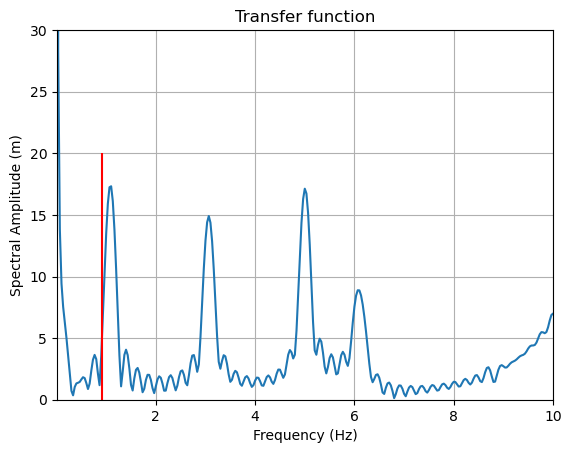

In [4]:
mat_list, layers = model()
xmin, xmax = np.min(XSTA),np.max(XSTA)
zmin = np.min(ZSTA)
stations = get_stations_from_layers(layers, (xmin, xmax), zmin, XSTA, ZSTA)

#p_val = 25/46
p_val = 0.0


# Signal de sortie (output)
output_velocity = Vx[:,stations[0]]
dt_o = Time_stations[1] - Time_stations[0]
FFT1, freq1 = fourier(zero_pad(output_velocity,5), dt_o, p=p_val)

# Signal d'entrée (input)
input_signal = np.genfromtxt(open(SEM.directory+'/inputp1','r'))
time = input_signal[:,0]
input_velocity = input_signal[:,1]
dt_i = time[1]-time[0]

# Padding à la bonne taille
FFT2, freq2 = fourier(zero_pad(input_velocity,3), dt_i)

FFT2_interp_func = interp1d(freq2, FFT2, kind='linear', fill_value="extrapolate")
FFT2_interp = FFT2_interp_func(freq1)  # spectre 2 interpolé sur les fréquences de spectre 1

ratio = FFT1 / FFT2_interp

H_star = np.sum(layers)
V_star = H_star/np.sum(layers/np.array([m.mat_dic['cs'] for m in mat_list]))
f0 = V_star/(4*H_star)
print(f0)

# Affichage
plt.plot(freq1, ratio)
plt.vlines(f0, 0, 20, colors='red')
#plt.xscale('log')
#plt.yscale('log')
plt.xlim([0.01,10])
plt.ylim([0,30])
plt.grid(True)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Spectral Amplitude (m)")
plt.title("Transfer function")

## Velocity Profile

Text(0.5, 1.0, 'Evolution of S-Wave velocity through depth')

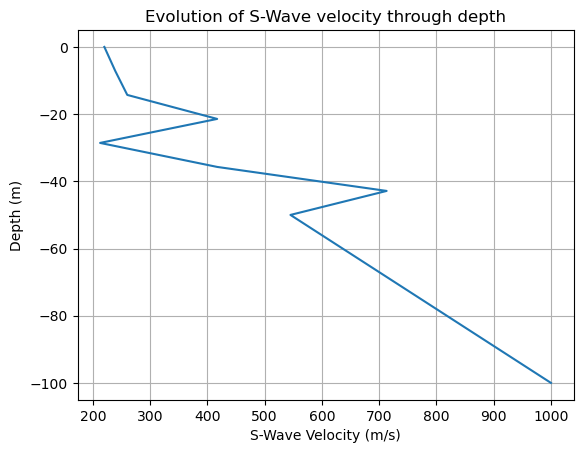

In [5]:
cs = np.array([m.mat_dic['cs'] for m in mat_list])
Z = np.linspace(0, zmin, cs.size)
plt.plot(cs, Z)
plt.grid(True)
plt.xlabel("S-Wave Velocity (m/s)")
plt.ylabel("Depth (m)")
plt.title("Evolution of S-Wave velocity through depth")